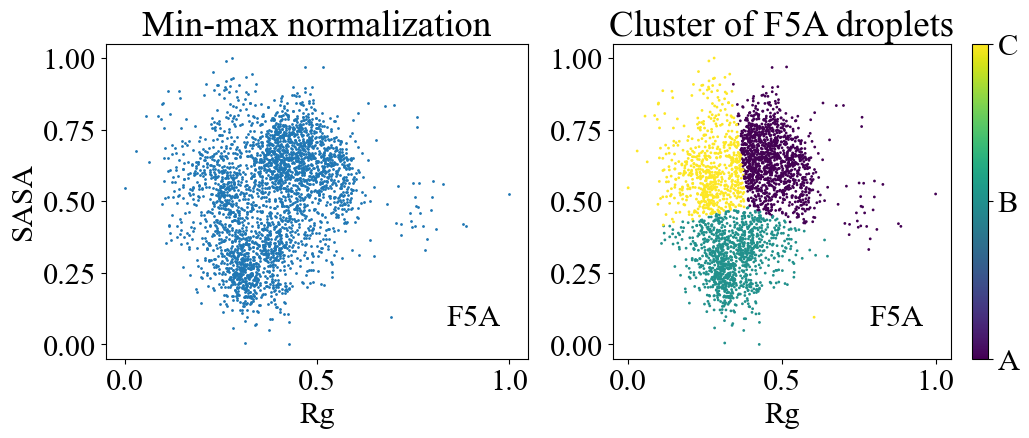

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

X = [] #x==Rg, y==SASA
t=[]

nox = []
noy = []
with open("sasa-rg.xvg",'r') as file:
    content=file.readlines()
    for index,lin in enumerate(content):
        t.append(index+1)
        X.append([eval(lin.split()[2]),eval(lin.split()[1])])
        nox.append(eval(lin.split()[2]))
        noy.append(eval(lin.split()[1]))
##max-min normalization

noxx = [0 for i in range(len(nox))]
noyy = [0 for i in range(len(nox))]
for index,val in enumerate(nox):
    noxx[index] = (val-min(nox))/(max(nox)-min(nox))

for index,val in enumerate(noy):
    noyy[index] = (val-min(noy))/(max(noy)-min(noy))
 
XX = []
for i in range(len(noxx)):
    XX.append([noxx[i],noyy[i]])

kmeans = KMeans(n_clusters=3, random_state=23)
kmeans.fit(XX)
 
centers = kmeans.cluster_centers_
labels = kmeans.labels_

#sns.set(font_scale=1.2)
plt.rc('font',family=['Times New Roman', 'SimSun'], size=22)
plt.figure(figsize=(12, 9))
plt.subplot(2,2,1)
plt.scatter(noxx,noyy,s=1,cmap='RdBu',label='F5A')
plt.xlabel('Rg')
plt.ylabel('SASA')
plt.title('Min-max normalization')
plt.legend(loc='lower right',frameon=False)

#plt.figure(figsize=(8, 6))
#print(np.array(X)[:,0])

plt.subplot(2,2,2)
scatter = plt.scatter(np.array(XX)[:,0],np.array(XX)[:,1],c=labels,s=1, cmap='viridis', alpha=1,label='F5A')#,label='F5A droplet')  #viridis指定渐变色
legend_handles = []
# plt.colorbar()
groups=['A','B','C']
plt.colorbar(scatter,ticks=range(0, 3)).set_ticklabels(groups)

plt.xlabel('Rg')
#plt.ylabel('SASA')
plt.title('Cluster of F5A droplets')
 
plt.legend(loc='best',frameon=False)
plt.show()



[2 1 1 ... 0 0 0]
[[0], [0], [0]]
[0.4218593802065978, 0.35288237254248583, 0.22525824725091637]


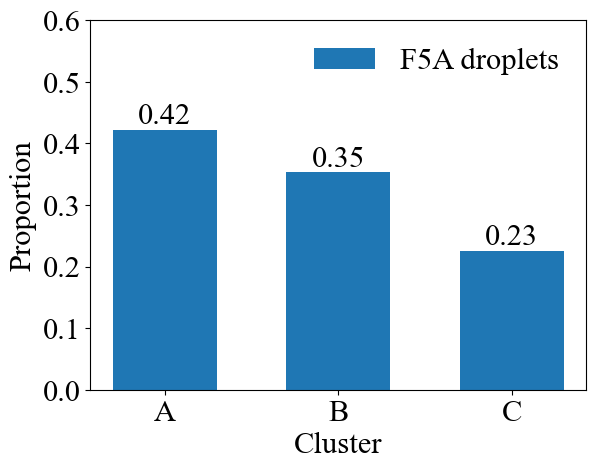

In [3]:

print(labels)

pct = [[0] for i in range(3)]
print(pct)

for index,line in enumerate(labels):
    pct[line][0]+=1

pcl = [x[0]/len(labels) for x in pct]

print(pcl)

import matplotlib.pyplot as plt
 

x = ['A','B','C']
y = pcl

lis=dict(zip(x,y))

lis_sorted = dict(sorted(lis.items(), key=lambda item: item[1], reverse=True))

xx = []
yy = []

for label,val in lis_sorted.items():
    xx.append(label)
    yy.append(val)

width = 0.6
plt.bar(xx, yy,width=width,label='F5A droplets')#,color=colors)

for value, label in zip(yy, xx):
    plt.text(label, value, str(round(value, 2)), ha='center', va='bottom')

plt.ylim(0,0.6)

plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(loc='upper right',frameon=False)
plt.show()

In [5]:
import math
with open('minmax.xvg','w') as file:
    indexlis = []
    for i in range(len(noxx)):
        file.write("{}  {}  {}\n".format(i+1,noxx[i],noyy[i]))
        indexlis.append(i+1)

centermax = centers[0]
distancelis = [np.linalg.norm(np.array(point) - np.array(centermax)) for point in XX]
dic = dict(zip(indexlis,distancelis))

dic_sorted = dict(sorted(dic.items(), key=lambda item: item[1], reverse=False))

print(centers)
print(dic_sorted)

[[0.47512282 0.64007695]
 [0.34201075 0.30546275]
 [0.26735922 0.61450426]]
{1451: 0.0028753892671624, 540: 0.010650515560999819, 1965: 0.011572893863419259, 1389: 0.011955623665526332, 1496: 0.012265470848484545, 1122: 0.013016208657060204, 1869: 0.013583931849437233, 1056: 0.014226777287221071, 1065: 0.014332093630299539, 1120: 0.014659006163096813, 1758: 0.014887055007881358, 2961: 0.015195163901918073, 1736: 0.015495515576565493, 1243: 0.015610351162721615, 1501: 0.01613272748020705, 1094: 0.016268092081457325, 1548: 0.016275985421723965, 1213: 0.01647003574279123, 1384: 0.01677376861417774, 1155: 0.016800029871241007, 2826: 0.01689259455343589, 2766: 0.01690985950115456, 1186: 0.01821890332274575, 2460: 0.01837050647820335, 2981: 0.01993779720659492, 1032: 0.019994347382616705, 1365: 0.02013066036247116, 1098: 0.020288742906578207, 1526: 0.02041122225816645, 2817: 0.020487729354353026, 1275: 0.020573899200665522, 1295: 0.020904194891389335, 2962: 0.021458481897858567, 1111: 0.0221

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


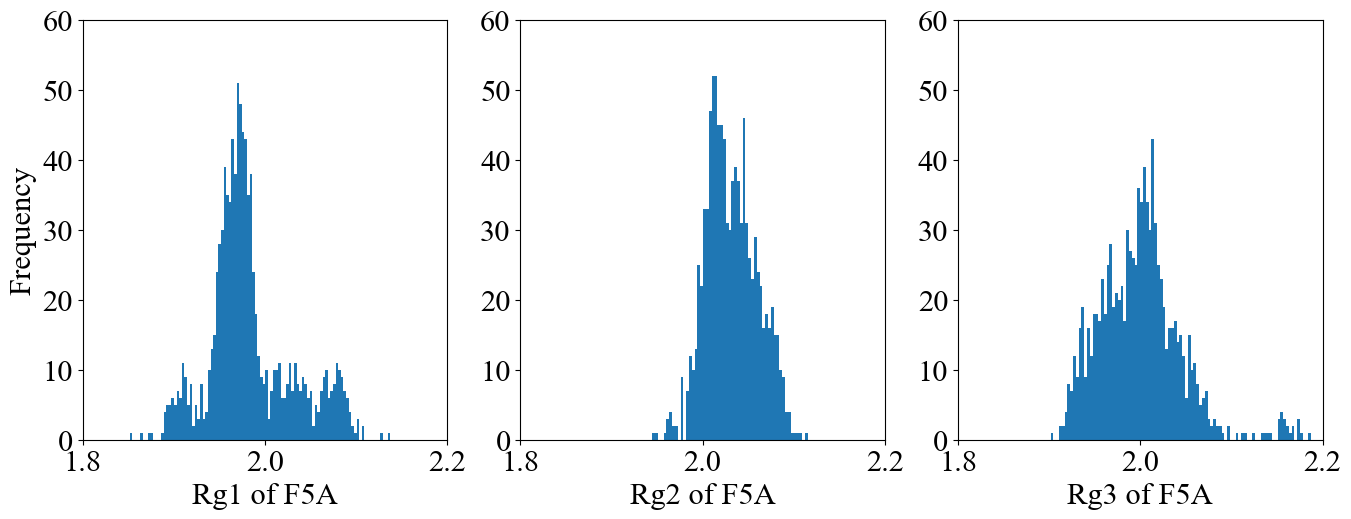

In [7]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

X = [] #x==Rg, y==SASA

Rg1 = []
Rg2 = []
Rg3 = []
with open("sasa-rg.xvg",'r') as file:
    content=file.readlines()
    for index,lin in enumerate(content):
        if index <= 999:
            Rg1.append(eval(lin.split()[2]))
        if index > 999 and index<=1999:
            Rg2.append(eval(lin.split()[2]))
        if index > 1999:
            Rg3.append(eval(lin.split()[2]))
    
plt.figure(figsize=(16, 12))
plt.subplot(2,3,1)
plt.ylim(0,60)
plt.xlim(1.8,2.2)
plt.hist(Rg1,bins=100)#,label='Trajectory 1 of F5A')
plt.xlabel('Rg1 of F5A')
plt.ylabel('Frequency')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,2)
plt.ylim(0,60)
plt.xlim(1.8,2.2)
plt.hist(Rg2,bins=100)#,label='Trajectory 2 of F5A')
plt.xlabel('Rg2 of F5A')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,3)
plt.ylim(0,60)
plt.xlim(1.8,2.2)
plt.hist(Rg3,bins=100)#,label='Trajectory 3 of F5A')
plt.xlabel('Rg3 of F5A')
plt.legend(loc='upper right',frameon=False)

plt.show()

##

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


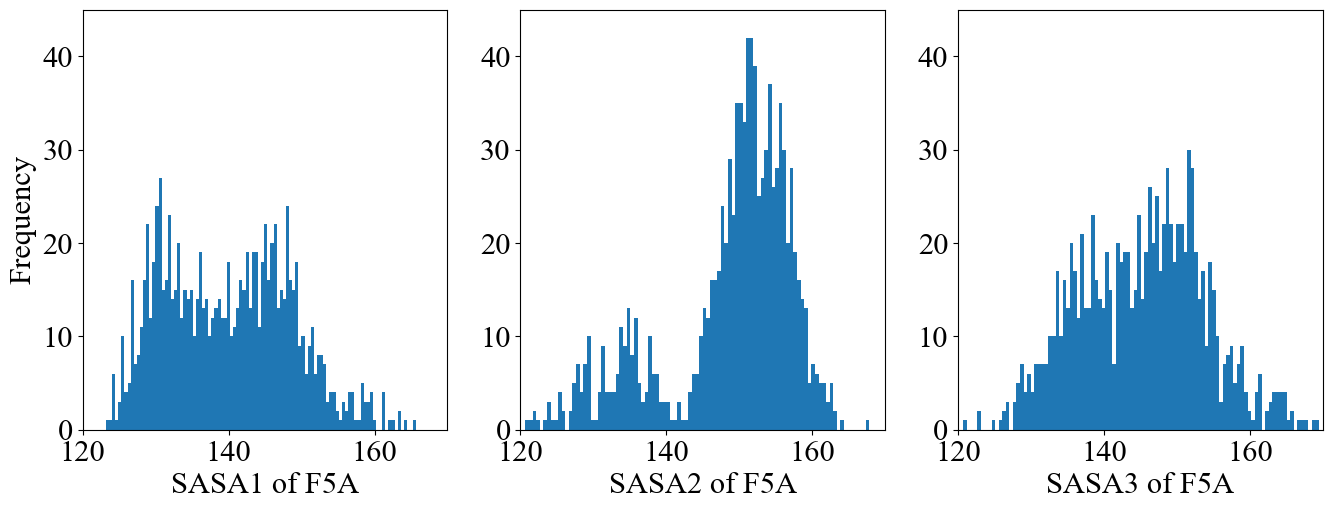

In [8]:


X = [] #x==Rg, y==SASA

SASA1 = []
SASA2 = []
SASA3 = []
with open("sasa-rg.xvg",'r') as file:
    content=file.readlines()
    for index,lin in enumerate(content):
        if index <= 999:
            SASA1.append(eval(lin.split()[1]))
        if index > 999 and index<=1999:
            SASA2.append(eval(lin.split()[1]))
        if index > 1999:
            SASA3.append(eval(lin.split()[1]))
    
plt.figure(figsize=(16, 12))
plt.subplot(2,3,1)
plt.ylim(0,45)
plt.xlim(120,170)
plt.hist(SASA1,bins=100)#,label='Trajectory 1 of F5A')
plt.xlabel('SASA1 of F5A')
plt.ylabel('Frequency')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,2)
plt.ylim(0,45)
plt.xlim(120,170)
plt.hist(SASA2,bins=100)#,label='Trajectory 2 of F5A')
plt.xlabel('SASA2 of F5A')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,3)
plt.ylim(0,45)
plt.xlim(120,170)
plt.hist(SASA3,bins=100)#,label='Trajectory 3 of F5A')
plt.xlabel('SASA3 of F5A')
plt.legend(loc='upper right',frameon=False)

plt.show()
